Load libraries and the dataset.

In [12]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

medical_df = pd.read_csv('medical.csv')
non_smoker_df = medical_df[medical_df['smoker'] == 'no']
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


Create a linear regression model.

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

Charges = w1*age + w2*BMI + b

Pick features and target for training.

In [14]:
inputs = non_smoker_df[['age', 'bmi']]
target = non_smoker_df['charges']
                    

Fit the model and generate predictions.

In [15]:
model.fit(inputs, target)
predicted_charges = model.predict(inputs)

Define an error metric for evaluation.

In [16]:
def rmse(predictions, actual):
    return np.sqrt(np.mean((predictions - actual) ** 2))

In [17]:
w = model.coef_
b = model.intercept_
print('w =', w)
print('b =', b)
print('RMSE =', rmse(predicted_charges, target))

w = [266.87657817   7.07547666]
b = -2293.6320906488727
RMSE = 4662.3128354612945


Visualize fit quality for the model.

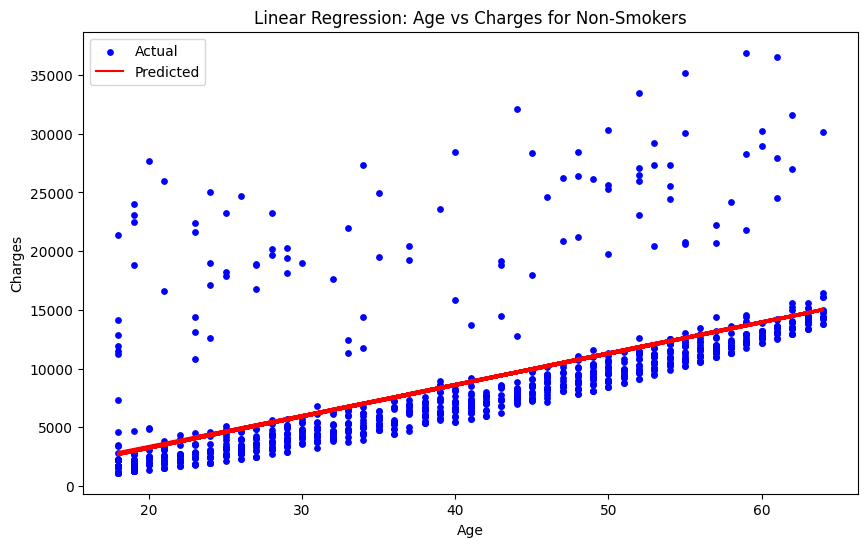

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(non_smoker_df['age'], target, color='blue', label='Actual',s=15)
plt.plot(non_smoker_df['age'], predicted_charges, color='red', label='Predicted')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Linear Regression: Age vs Charges for Non-Smokers')
plt.legend()
plt.show()